# REXIA-Responsible and Explainable AI


Nicolas Charrondiere

Paul Guimbert

## Partie 1: Données tabulaires

In [ ]:
import pandas as pd

df = pd.read_csv('data/RH_dataset.csv', sep=';')
df.head(10)

### Analyse du jeu de données

In [ ]:
print(f'{len(df.columns)} colonnes : ')
print(*df.columns, sep='\n')

14 colonnes:
- 2 variables catégorielles : Famille d'emploi, Statut marital
- 12 variables numériques : Dernière promotion (mois), Dernière augmentation (mois), Début de contrat (années),Ancienneté groupe (années), Etablissement, Âge (années), Parent,Niveau hiérarchique, Salaire (Euros), Véhicule,matricule, label

In [ ]:
# Somme des valeurs manquantes par colonne
missing_count = df.isnull().sum()
print(missing_count)

Il n'y a pas de valeur manquantes dans le dataset

In [ ]:
df.describe()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution de l'âge ou du salaire selon la démission (classe 0 ou 1)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Salaire (Euros)', hue='label', fill=True)
plt.title("Distribution des salaires selon le statut de démission")
plt.show()

# Boxplot pour les plages de valeurs
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='label', y='Ancienneté groupe (années)')
plt.title("Plage d'ancienneté selon la démission")
plt.show()

Les gens qui démissionnent sont là depuis moins longtemps.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Palette de couleurs
palette_colors = {0: "skyblue", 1: "salmon"}

for col in [c for c in df.columns if c != 'label']:
    plt.figure(figsize=(10, 5))

    # --- CAS NUMÉRIQUE : On utilise KDE (densité de probabilité) ---
    if df[col].dtype in ['int64', 'float64']:
        # common_norm=False force chaque courbe à avoir une surface de 1
        # Cela permet de comparer les formes même si les effectifs sont différents
        sns.kdeplot(data=df, x=col, hue='label', fill=True,
                    palette=palette_colors, common_norm=False, alpha=0.5)
        plt.title(f"Comparaison des densités (Normalisées) : {col}")

    # --- CAS CATÉGORIEL : On utilise les probabilités ---
    else:
        # stat="probability" et common_norm=False calculent le % au sein de chaque classe
        sns.histplot(data=df, x=col, hue='label', palette=palette_colors,
                     stat="probability", common_norm=False, multiple="dodge", shrink=.8)
        plt.xticks(rotation=45)
        plt.title(f"Distribution relative des catégories (Normalisée) : {col}")
        plt.ylabel("Proportion au sein de la classe")

    plt.tight_layout()
    plt.show()

In [ ]:
# Un employé qui a démissionné (label 1)
print("Profil d'un employé ayant démissionné :")
display(df[df['label'] == 1].head(1))

# Un employé qui est resté (label 0)
print("\nProfil d'un employé n'ayant pas démissionné :")
display(df[df['label'] == 0].head(1))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_numeric = df.select_dtypes(include=['number'])

# Calculer la matrice de corrélation
# On utilise la méthode de Pearson par défaut
corr = df_numeric.corr()

plt.figure(figsize=(8, 8))  # Ajuste la taille selon ton nombre de colonnes

sns.heatmap(
    corr,
    annot=True,           # Affiche les scores de corrélation dans les cases
    fmt=".2f",            # Format à 2 décimales
    # Palette : bleu (négatif), blanc (neutre), rouge (positif)
    cmap='coolwarm',
    linewidths=0.5,       # Ajoute un petit filet entre les cases
    center=0,             # Définit 0 comme le point central de la couleur
    vmin=-1, vmax=1       # Force l'échelle entre -1 et 1
)

plt.title("Matrice de Corrélation")
plt.show()

Il y a peu de corrélation directe entre les variables et le label.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Créer un tableau de pourcentages
# On calcule la moyenne du label (qui est 0 ou 1) par statut marital.
# Cela donne directement le taux de démission (ex: 0.25 = 25% de démissions)
stats_marital = df.groupby('Statut marital')['label'].mean(
).sort_values(ascending=False).reset_index()
stats_marital.columns = ['Statut marital', 'Taux de démission']

# 2. Tracer le graphique
plt.figure(figsize=(10, 6))
sns.barplot(data=stats_marital, x='Statut marital',
            y='Taux de démission')

plt.title("Taux de démission selon le Statut Marital")
plt.ylabel("Proportion de démissions (Label 1)")
plt.axhline(df['label'].mean(), color='red',
            linestyle='--', label='Moyenne globale')
plt.legend()
plt.show()

In [ ]:
# Tableau croisé en effectifs
cross_tab = pd.crosstab(df['Statut marital'], df['label'], margins=True)
print("Tableau de contingence :")
display(cross_tab)

# Tableau croisé en pourcentages (plus facile à interpréter)
cross_tab_pct = pd.crosstab(
    df['Statut marital'], df['label'], normalize='index') * 100
print("\nPourcentage de démission par catégorie :")
display(cross_tab_pct)

L'analyse du taux de démission par statut marital révèle que les employés célibataires présentent le taux de démission le plus élevé (5,60 %), suivis des personnes en concubinage (3,61 %), tandis que les employés veufs ou ex-PACS sont les plus stables. Cette disparité suggère que la situation familiale pourrait être un facteur d'influence sur la mobilité des employés dans ce jeu de données.

### Analyse des variables sensibles et biais potentiels

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Correction de Yates pour les petits échantillons si nécessaire
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Exemple : Lien entre Famille d'emploi et Statut Marital
print(f"V de Cramer : {cramers_v(df['Famille d\'emploi'], df['Statut marital']):.2f}")

In [ ]:
def correlation_ratio(categories, values):
    f_obs = values.groupby(categories).apply(list)
    # Calcul de la somme des carrés totale (SST)
    ss_total = np.sum((values - values.mean())**2)
    # Calcul de la somme des carrés inter-groupes (SSB)
    category_means = values.groupby(categories).mean()
    category_counts = values.groupby(categories).count()
    ss_between = np.sum(category_counts * (category_means - values.mean())**2)
    
    return ss_between / ss_total

# Exemple : Est-ce que le Salaire dépend du Statut Marital ?
eta = correlation_ratio(df['Statut marital'], df['Salaire (Euros)'])
print(f"Ratio de corrélation (Eta^2) : {eta:.2f}")

### Apprentissage automatique

### Partie 2:

### Partie 3:

## Partie 2: Données images

### 1) Analyse du jeu de données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Analyse Descriptive du jeu de données

In [15]:
# Lecture de tout les csv
df_attr = pd.read_csv("data/CelebA/list_attr_celeba.csv")
df_bbox = pd.read_csv("data/CelebA/list_bbox_celeba.csv")
df_partition = pd.read_csv("data/CelebA/list_eval_partition.csv")
df_landmarks = pd.read_csv("data/CelebA/list_landmarks_align_celeba.csv")

In [19]:
# df_attr contient les attributs pour chaque image 
# (identifié via image_id qui contient le nom du fichier)
# avec la valeur 1 s'il est dans l'image et -1 sinon
df_attr.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [20]:
# df_bbox contient les informations de la bounding box contenant 
# les informations pour chaque image
df_bbox.head()

,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126
3,000004.jpg,622,257,564,781
4,000005.jpg,236,109,120,166


In [21]:
# df_partition indique pour chaque image dans quelle parition elle est
# 0 = train, 1 = validation, 2 = test
df_partition.head()

,image_id,partition
0,000001.jpg,0
1,000002.jpg,0
2,000003.jpg,0
3,000004.jpg,0
4,000005.jpg,0


In [ ]:
# df_landmarks contient pour chaque image les coordonnees (x,y) 
# de cinq points caractéristiques présents sur chaque visage : 
# left eye, right eye, nose, left mouth, right mouth.
df_landmarks.head()

,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,69,109,106,113,77,142,73,152,108,154
1,000002.jpg,69,110,107,112,81,135,70,151,108,153
2,000003.jpg,76,112,104,106,108,128,74,156,98,158
3,000004.jpg,72,113,108,108,101,138,71,155,101,151
4,000005.jpg,66,114,112,112,86,119,71,147,104,150


In [23]:
print(f"Le jeu de données contient {len(df_attr)} images")

Le jeu de données contient 202599 images


In [31]:
df_attr.columns

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young'],
      dtype='str')

Il y a 40 classes possibles pour chaque image, décrivant des traits physique plus ou moins subjectifs. Je remarque nottament "young" ou encore "attractive" qui sont assez subjectifs à l'inverse de "mustache" ou encore "bald".

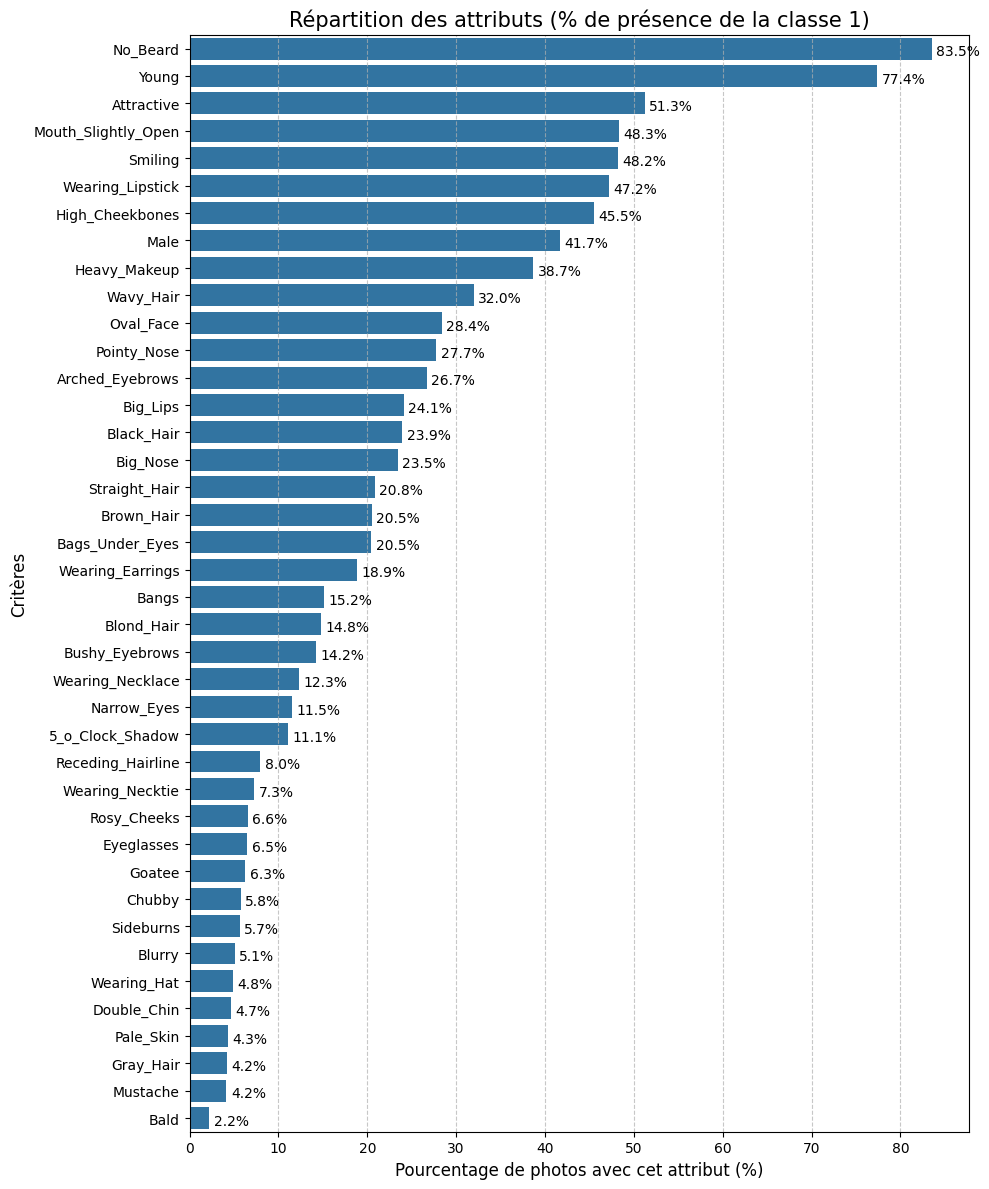

In [32]:
# Calcul du pourcentage des images possédant chaque classe
# et tracé d'un histogramme ordonné du plus au moins présent de haut en bas

df_attr_numeric = df_attr.iloc[:, 1:]
df_attr_binary = df_attr_numeric.replace(-1, 0)
percentages_attr = df_attr_binary.mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 12))
sns.barplot(x=percentages_attr.values, y=percentages_attr.index)

plt.title('Répartition des attributs (% de présence de la classe 1)', fontsize=15)
plt.xlabel('Pourcentage de photos avec cet attribut (%)', fontsize=12)
plt.ylabel('Critères', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, v in enumerate(percentages_attr.values):
    plt.text(v + 0.5, i + .25, f"{v:.1f}%", color='black', fontsize=10)

plt.tight_layout()
plt.show()

La distribution des classes varie fortement, allant de environ 2% pour les moins présentes (chauves, moustache) à plus de 80% pour l'absence de barbe. Je remarque une légère sur représentation des attributs "absence de barbe" et "jeune" qui sont resepctivement présent pour 83.5% et 77.4% des images, alors que le troisième attribut le plus présent ne l'est qu'à 51.3%, soit plus de 25% d'écart.

#### Analyse des corrélations

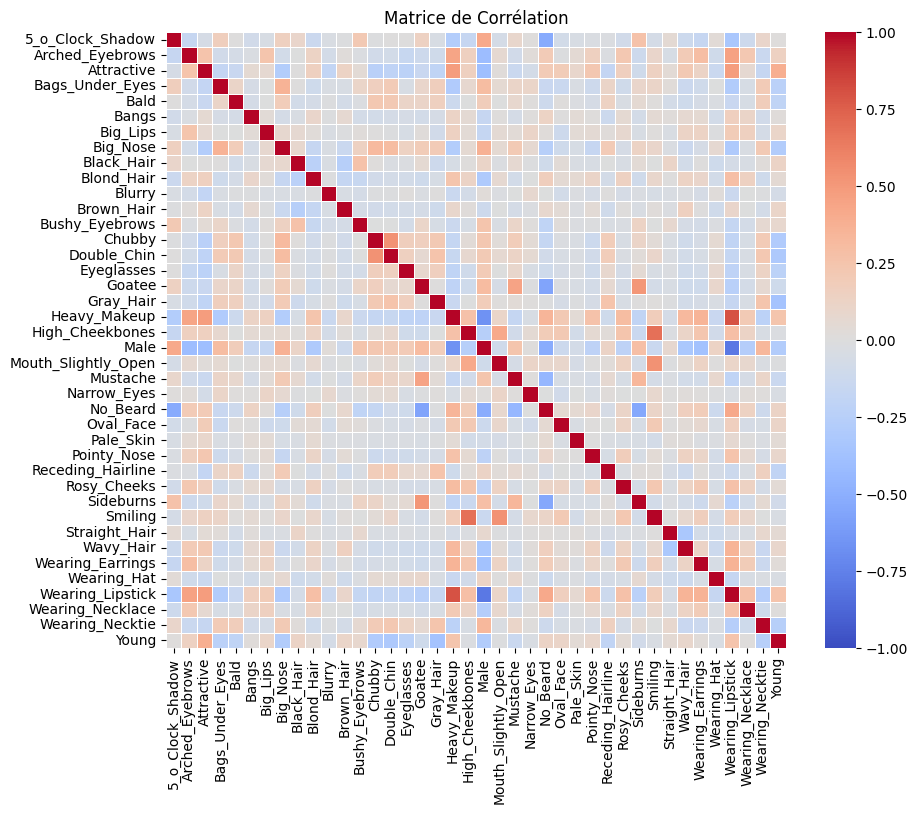

In [36]:
# Calculer la matrice de corrélation
# On utilise la méthode de Pearson par défaut
corr = df_attr_numeric.corr()

plt.figure(figsize=(10, 8))  # Ajuste la taille selon ton nombre de colonnes

sns.heatmap(
    corr,
    annot=False,           # Affiche les scores de corrélation dans les cases
    # Palette : bleu (négatif), blanc (neutre), rouge (positif)
    cmap='coolwarm',
    linewidths=0.5,       # Ajoute un petit filet entre les cases
    center=0,             # Définit 0 comme le point central de la couleur
    vmin=-1, vmax=1       # Force l'échelle entre -1 et 1
)

plt.title("Matrice de Corrélation")
plt.show()

In [38]:
# Extraction des correlations les plus fortes
sol = corr.abs().unstack()
sol = sol.sort_values(ascending=False)

# On retire les corrélations de 1 (une variable avec elle-même)
top_corr = sol[sol < 1].head(30)

print("Top 20 des corrélations les plus fortes :")
print(top_corr)

Top 20 des corrélations les plus fortes :
Heavy_Makeup         Wearing_Lipstick       0.801539
Wearing_Lipstick     Heavy_Makeup           0.801539
                     Male                   0.789435
Male                 Wearing_Lipstick       0.789435
High_Cheekbones      Smiling                0.683497
Smiling              High_Cheekbones        0.683497
Male                 Heavy_Makeup           0.666724
Heavy_Makeup         Male                   0.666724
Goatee               No_Beard               0.570071
No_Beard             Goatee                 0.570071
Sideburns            No_Beard               0.543061
No_Beard             Sideburns              0.543061
Mouth_Slightly_Open  Smiling                0.536379
Smiling              Mouth_Slightly_Open    0.536379
Chubby               Double_Chin            0.533713
Double_Chin          Chubby                 0.533713
No_Beard             5_o_Clock_Shadow       0.526946
5_o_Clock_Shadow     No_Beard               0.526946
No_B

On retrouve des corrélations logiques entre les attributs de maquillage ("heavy_makeup", "Wearing_Lipstick") qui sont positivement corrélés entre eux et inversement corrélés au critère "male", ce qui correspond à l'intuition qu'on peut avoir : les hommes ont beaucoup moins tendance à porter du maquillage et quelqu'un qui porte du rouge a lèvre a plus de chance d'être fortement maquillée. L'attribut d'attractivité est également lié au maquillage.

D'autres liens logique apparaissent entre les différents attributs décrivant la pilosité faciale, et le sourire.

La corrélation de 0.80 entre "Heavy_Makeup" et "Wearing_Lipstick" peut être considéré comme partiellement artificielle" car pour l'annotateur il doit être plutôt rare d'annoter une image "Heavy_Makeup" si elle n'est pas "Wearing_Lipstick".

Il y a également le cas de la corrélation de 0.52 entre "Male" et "No_Beard" qui est biaisé par le fait que l'abscence de barbe est largement la norme chez les femmes.

Le risque de ces corrélations artificielles est que notre modèle pourrait apprendre que "tous les gens qui sourient ont des pommettes hautes", ce qui est un biais.

#### Identification des variables sensibles

Une variable est dite sensible lorsqu'elle peut entraîner une discrimination ou un traitement injuste si elle est utilisée de manière inappropriée par nos modèles.

Dans notre cas, nous identifions 3 variables sensibles:
- "Male" : Un modèle pourrait apprendre des préjugés sexistes (ex: associer la compétence ou une émotion uniquement à un genre).
- "Young" : L'âge peut mener à l'exclusion sociale ou professionnelle. Ici comme cette variable est binaire, cette influence pourrait être forte, plus que si on possédait l'âge exacte.
- "Pale_Skin" : Cet attribut est un indicateur indirecte de la couleur de peau, ce qui est une information très sensible pour les risques de racisme algorithmique.

Ces trois attributs sont clairement sensibles. Il faudra également préter attention aux attributs qui leur sont fortement corréllés ("Male" et les attributs de pilosité faciales nottament), par lesquels les biais pourrait se retrouver.

#### Analyse de disparité

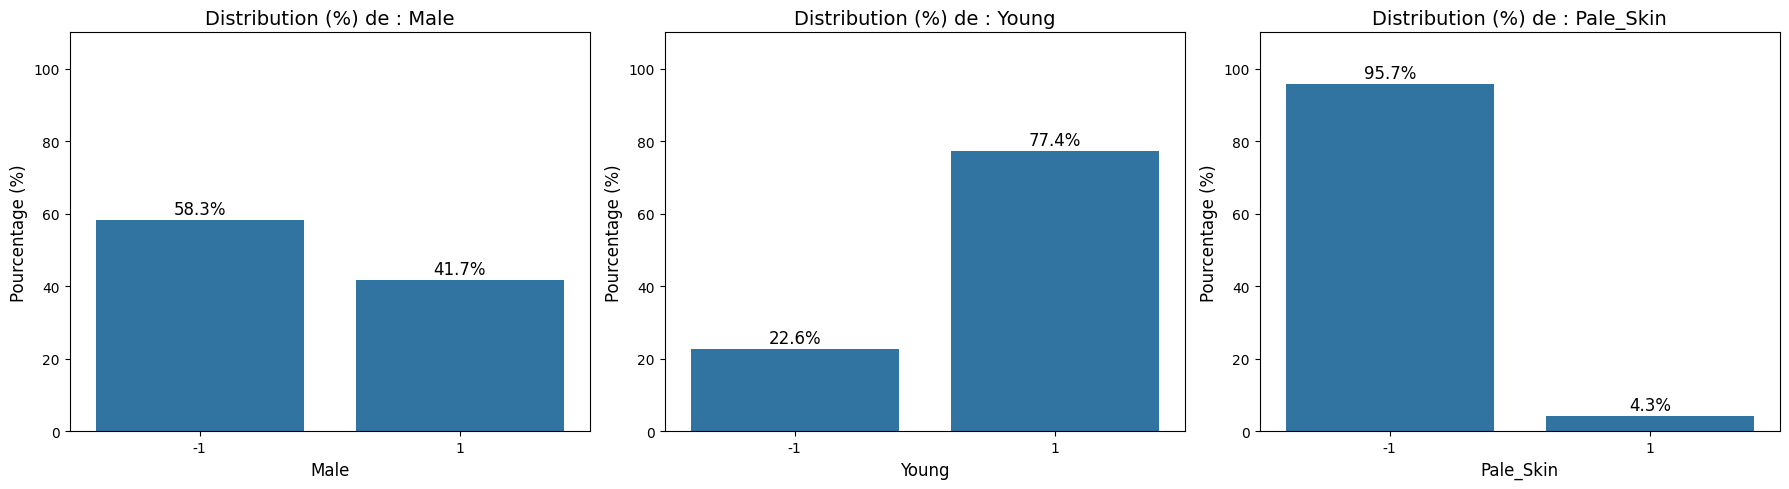

In [42]:
# Analyse de la disparité pour les groupes sensibles
attributs_sensibles = ['Male', 'Young', 'Pale_Skin']

plt.figure(figsize=(18, 5))

for i, col in enumerate(attributs_sensibles):
    plt.subplot(1, 3, i + 1)

    # CALCUL : On calcule la fréquence relative (normalize=True) et on multiplie par 100
    counts = df_attr_numeric[col].value_counts(
        normalize=True).sort_index() * 100

    # TRACÉ : Utilisation de sns.barplot puisque nous avons déjà calculé les valeurs
    ax = sns.barplot(x=counts.index, y=counts.values)

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    fontsize=12, color='black',
                    xytext=(0, 8),
                    textcoords='offset points')

    plt.title(f'Distribution (%) de : {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Pourcentage (%)', fontsize=12)
    plt.ylim(0, 110)
    plt.xticks(rotation=0)

# Ajustement final
plt.tight_layout()
plt.show()

Il y a des déséquilibres au niveau de ces groupes, avec un legere surdominance des femmes dans le dataset et une forte dominance des jeunes et des peau non pâles. Ces données indiquent clairement un biais de collecte et / ou d'annotation.

On peut également analyser les disparités de certains attributs au sein des groupes.

In [62]:
# Analyse de la disparité de crit2 au sein des groupes défini par crit1
def crossed_disparity(df:pd.DataFrame, crit1:str, crit2:str, show=False):
    disparity = df.groupby(crit1)[crit2].value_counts(
        normalize=True).unstack() * 100

    if show:
        plt.figure(figsize=(10, 6))

        annot_labels = disparity.map(lambda x: f"{x:.1f}%").values
        
        # Dessin de la heatmap
        sns.heatmap(disparity,
                    annot=annot_labels,
                    fmt="",
                    vmin=0,
                    vmax=100,
                    cbar_kws={'label': 'Pourcentage (%)'},
                    annot_kws={"size": 13})

        # Personnalisation des titres et axes
        plt.title(
            f'Analyse de Disparité Croisée : {crit1} vs {crit2}', fontsize=15, pad=20)
        plt.ylabel(f'Attribut Sensible ({crit1})', fontsize=12)
        plt.xlabel(f'Cible ({crit2})', fontsize=12)

        # Si tes données sont en 0/1, tu peux renommer les axes pour plus de clarté
        # plt.xticks([0.5, 1.5], ['Non (0)', 'Oui (1)'])
        # plt.yticks([0.5, 1.5], ['Non (0)', 'Oui (1)'])

        plt.show()
    
    return disparity

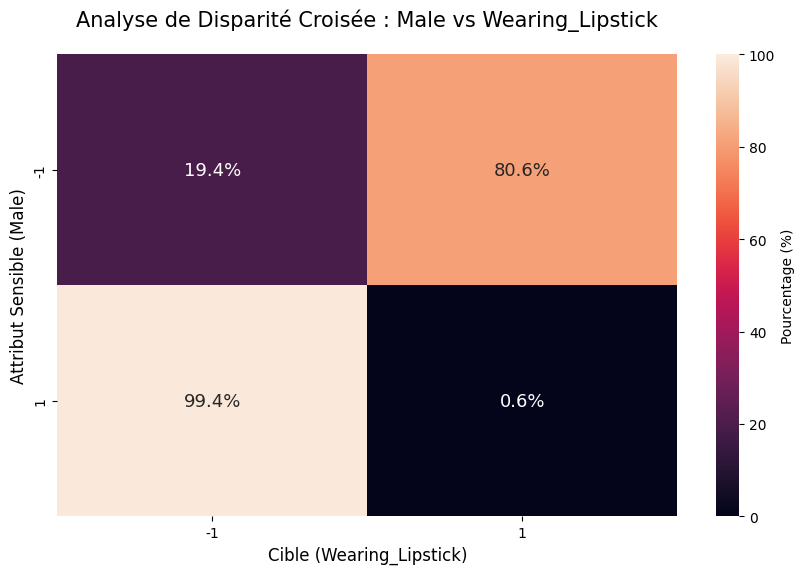

In [ ]:
_ = crossed_disparity(df_attr, 'Male', 'Wearing_Lipstick', show=True)

In [66]:
def find_most_biased_targets(df:pd.DataFrame, sensitive_attr):
    results = []
    target_lists = [col for col in df.columns if col != sensitive_attr and col != 'image_id']
    for target in target_lists:
        disparity_df = crossed_disparity(df_attr, sensitive_attr, target, show=False)

        group_neg_val = disparity_df.loc[-1, 1]
        group_pos_val = disparity_df.loc[1, 1]

        gap = abs(group_neg_val - group_pos_val)

        results.append({
            'Target': target,
            'Gap (%)': gap,
            'Value_Group_neg': group_neg_val,
            'Value_Group_pos': group_pos_val
        })

    summary = pd.DataFrame(results).sort_values(by='Gap (%)', ascending=False)
    return summary

In [70]:
for attribut in attributs_sensibles:
    diagnostic = find_most_biased_targets(df_attr, attribut)
    print(f"\nAttributs les plus biaisés pour le groupement par '{attribut}'")
    print(diagnostic.head(10))
    


Attributs les plus biaisés pour le groupement par 'Male'
              Target    Gap (%)  Value_Group_neg  Value_Group_pos
35  Wearing_Lipstick  79.939122        80.558541         0.619419
18      Heavy_Makeup  65.864273        66.141412         0.277140
2         Attractive  39.990942        67.916896        27.925954
23          No_Beard  39.323825        99.882368        60.558543
1    Arched_Eyebrows  36.610737        41.955740         5.345003
7           Big_Nose  31.735729        10.227225        41.962953
32         Wavy_Hair  30.642915        44.727288        14.084374
33  Wearing_Earrings  29.652673        31.250370         1.597698
0   5_o_Clock_Shadow  26.626370         0.016925        26.643295
19   High_Cheekbones  25.267470        56.033512        30.766042

Attributs les plus biaisés pour le groupement par 'Young'
              Target    Gap (%)  Value_Group_neg  Value_Group_pos
2         Attractive  46.311006        15.423526        61.734531
20              Male  33.

On observe des biais fort entre les attributs sensibles et d'autres variables : 'Male' et 'Wearing Lipstick' et 'Heavy_Makeu' nottament. 'Young' et 'Attractive' et 'Male'. Cela est un peu moins le cas pour 'Pale_Skin' mais on observe quand même plus de personnes jugées "Attractive" pour les personnes avec une "pale_skin"

#### Analyse de la fairness

In [ ]:
import pandas as pd


def calculate_fairness_metrics(df, s_col, y_col):
    """
    Calcule la Demographic Parity et le Disparate Impact entre deux groupes.
    S=1 (Groupe protégé) vs S=0 ou -1 (Groupe de référence)
    """
    values = sorted(df[s_col].unique(), reverse=True)
    s_positive = values[0]  # S = 1
    s_negative = values[1]  # S = -1 ou 0

    prob_y1_s1 = df[df[s_col] == s_positive][y_col].mean()
    prob_y1_s_neg = df[df[s_col] == s_negative][y_col].mean()

    demographic_parity = abs(prob_y1_s1 - prob_y1_s_neg)

    disparate_impact = prob_y1_s1 / prob_y1_s_neg if prob_y1_s_neg != 0 else float('inf')

    return {
        'S_attr': s_col,
        'Y_attr': y_col,
        'P(Y=1|S=1)': prob_y1_s1,
        'P(Y=1|S=-1)': prob_y1_s_neg,
        'Demographic Parity': demographic_parity,
        'Disparate Impact': disparate_impact
    }

In [81]:
all_results = []

sensible_list = ['Male', 'Pale_Skin']

for s_attr in sensible_list:
    other_attributes = [
        col for col in df_attr.columns if col != s_attr and col != 'image_id']

    for y_attr in other_attributes:
        metrics = calculate_fairness_metrics(df_attr, s_attr, y_attr)
        all_results.append(metrics)

df_fairness_summary = pd.DataFrame(all_results)
df_fairness_summary = df_fairness_summary.sort_values(by='Demographic Parity', ascending=False)

In [77]:
df_fairness_summary.head(10)

,S_attr,Y_attr,P(Y=1|S=1),P(Y=1|S=-1),Demographic Parity,Disparate Impact
34,Male,Wearing_Lipstick,-0.987612,0.611171,1.598782,-1.615934
18,Male,Heavy_Makeup,-0.994457,0.322828,1.317285,-3.080453
2,Male,Attractive,-0.441481,0.358338,0.799819,-1.232024
23,Male,No_Beard,0.211171,0.997647,0.786477,0.211669
1,Male,Arched_Eyebrows,-0.893100,-0.160885,0.732215,5.551163
7,Male,Big_Nose,-0.160741,-0.795456,0.634715,0.202074
31,Male,Wavy_Hair,-0.718313,-0.105454,0.612858,6.811604
32,Male,Wearing_Earrings,-0.968046,-0.374993,0.593053,2.581507
0,Male,5_o_Clock_Shadow,-0.467134,-0.999661,0.532527,0.467292
19,Male,High_Cheekbones,-0.384679,0.120670,0.505349,-3.187854


In [82]:
# On peut analyser en particulier le cas pour S='Pale_Skin' et Y='Attractive'
result_male_skin = df_fairness_summary[(df_fairness_summary['S_attr'] == 'Pale_Skin') &
                                        (df_fairness_summary['Y_attr'] == 'Attractive')]

result_male_skin

,S_attr,Y_attr,P(Y=1|S=1),P(Y=1|S=-1),Demographic Parity,Disparate Impact
41,Pale_Skin,Attractive,0.4311,0.006787,0.424313,63.517784


$P(Y=1 | S=1) = 43.1\%$ : Près de la moitié des personnes ayant la peau claire sont également "attrayantes".

$P(Y=1 | S=-1) = 0.68\%$ : Moins de $1\%$ des personnes n'ayant pas la peau claire sont considérées comme "attrayantes".

La "Demographic Parity" de $0.424$ est énorme. Idéalement ce score devrait être proche de $0$ dans le cas équitable. Cela montre qu'il existe une corrélation massive entre la couleur de peau et le label "Attractive" dans le jeu de données. 

Le "Disparate impact" de $63.52$ signifique qu'une personne à peau claire a 63,5 fois plus de chances d'être étiquetée comme "attrayante" qu'une personne n'ayant pas la peau claire dans ce dataset, ce qui est un biais de discrimination systémique majeur.

### 2) Apprentissage automatique 

### 3) Explication post-hoc